### Step 1: Project Title and Objective

# Credit Card Default Prediction

The objective of this project is to build a machine learning classification model to predict whether a credit card customer will default on payment in the next month.

This project will help banks identify high-risk customers, reduce credit risk, and make better financial decisions.

### Step 2: Import Required Libraries

In [1]:
# Step 2: Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

### Step 3: Load Dataset

In [2]:
# Step 3: Load the Dataset

df = pd.read_csv("Credit_Card_Default.csv")

# Display first 5 rows
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


### Step 4: Check Dataset Shape

In [3]:
# Step 4: Check Shape of Dataset

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 30000
Number of Columns : 25


### Step 5: Check Column Names

In [4]:
# Step 5: Display Column Names

df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')

### Step 6: Dataset Information

In [5]:
# Step 6: Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

### Step 7: Statistical Summary

In [6]:
# Step 7: Statistical Summary

df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


### Step 8: Check Missing Values

In [7]:
# Step 8: Check Missing Values

df.isnull().sum()


ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

### Step 9: Check Duplicate Rows


In [8]:
# Step 9: Check Duplicate Rows

df.duplicated().sum()

0

### Step 10: Initial Observations



- The dataset contains 30,000 customer records and 25 columns.
- The dataset contains both demographic and financial information of credit card customers.
- There are no missing values present in the dataset.
- No duplicate rows were found in the dataset.
- Most columns are numerical in nature.
- The target column is `default.payment.next.month`, which indicates whether the customer will default on payment in the next month.
- Variables such as PAY_0 to PAY_6 represent repayment history.
- Variables such as BILL_AMT1 to BILL_AMT6 represent bill statement amounts.
- Variables such as PAY_AMT1 to PAY_AMT6 represent previous payment amounts.
- Some financial variables contain large ranges and possible outliers.

### Step 11: Rename Target Column

In [9]:
# Step 11: Rename Target Column

df.rename(columns={
    'default.payment.next.month': 'DEFAULT'
}, inplace=True)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


### Step 12: Target Variable Distribution

In [10]:
# Step 12: Target Variable Distribution

df['DEFAULT'].value_counts()

DEFAULT
0    23364
1     6636
Name: count, dtype: int64

### Step 13: Target Variable Percentage

In [11]:
# Step 13: Percentage Distribution of Target Variable

df['DEFAULT'].value_counts(normalize=True) * 100

DEFAULT
0    77.88
1    22.12
Name: proportion, dtype: float64

### Step 14: Visualize Target Variable

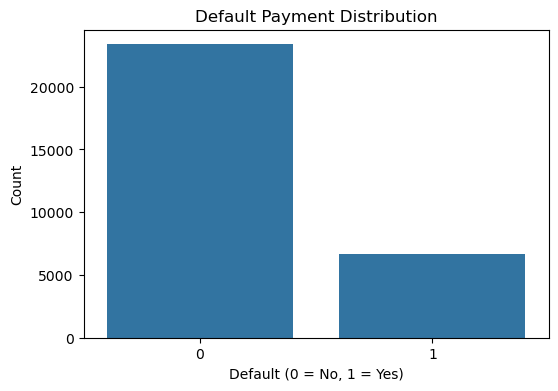

In [12]:
# Step 14: Visualize Target Variable

plt.figure(figsize=(6,4))

sns.countplot(x='DEFAULT', data=df)

plt.title('Default Payment Distribution')
plt.xlabel('Default (0 = No, 1 = Yes)')
plt.ylabel('Count')

plt.show()

### Step 15: Interpretation of Target Variable

- DEFAULT = 0 represents customers who did not default on payment.
- DEFAULT = 1 represents customers who defaulted on payment.
- Approximately 77.88% customers did not default, while 22.12% customers defaulted on payment.
- The dataset is moderately imbalanced, with non-default customers being higher than default customers.
- Understanding the target variable distribution is important before training classification models.

### Step 16: Gender Distribution

In [13]:
# Step 16: Gender Distribution

df['SEX'].value_counts()

SEX
2    18112
1    11888
Name: count, dtype: int64

### Step 17: Gender Distribution Visualization

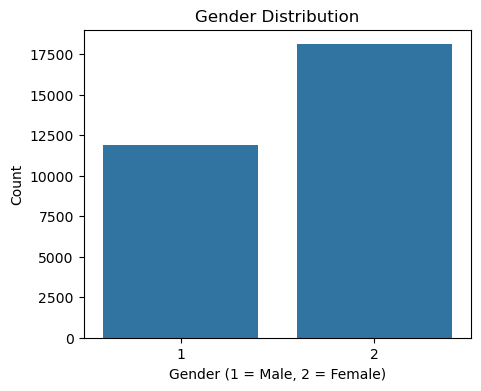

In [14]:
# Step 17: Visualize Gender Distribution

plt.figure(figsize=(5,4))

sns.countplot(x='SEX', data=df)

plt.title('Gender Distribution')
plt.xlabel('Gender (1 = Male, 2 = Female)')
plt.ylabel('Count')

plt.show()

### Step 18: Gender Analysis Interpretation

- The dataset contains both male and female credit card customers.
- Female customers are higher in number compared to male customers.
- In this dataset:
  - 1 represents Male
  - 2 represents Female
- Gender distribution helps understand customer demographics and may help analyze repayment behavior.

### Step 19: Age Distribution

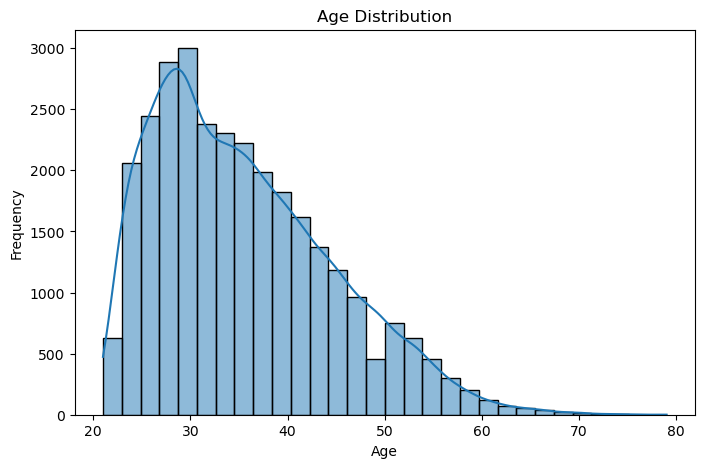

In [15]:
# Step 19: Age Distribution

plt.figure(figsize=(8,5))

sns.histplot(df['AGE'], bins=30, kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

### Step 20: Age Analysis Interpretation

- Most credit card customers belong to the age group of approximately 25 to 40 years.
- The highest concentration of customers is observed around the late 20s and early 30s.
- The age distribution is slightly right-skewed, indicating fewer older customers.
- Very few customers are above 60 years of age.
- Age may influence repayment behavior and credit default risk.

### Step 21: Credit Limit Distribution

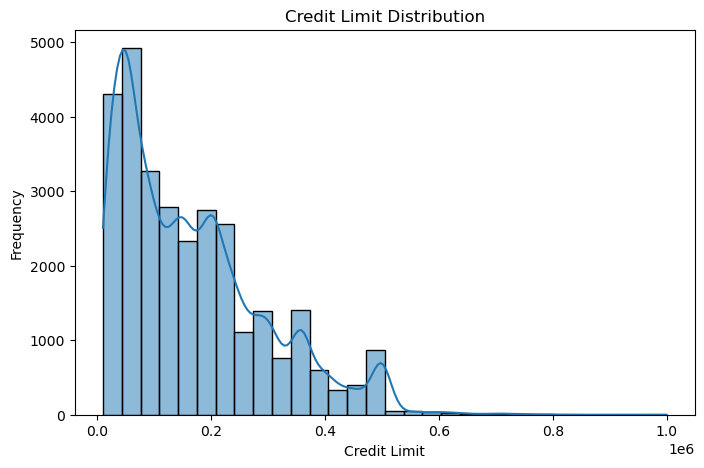

In [16]:
# Step 21: Credit Limit Distribution

plt.figure(figsize=(8,5))

sns.histplot(df['LIMIT_BAL'], bins=30, kde=True)

plt.title('Credit Limit Distribution')
plt.xlabel('Credit Limit')
plt.ylabel('Frequency')

plt.show()

### Step 22: Credit Limit Distribution Analysis

- Most customers have lower to medium credit limits.
- The distribution is positively skewed (right-skewed), with a small number of customers having very high credit limits.
- Majority of the observations are concentrated in the lower credit limit range.
- Few outliers with extremely high credit limits are present.
- Credit limit may play an important role in predicting default payment behavior.

### Step 23: BILL_AMT1 Distribution


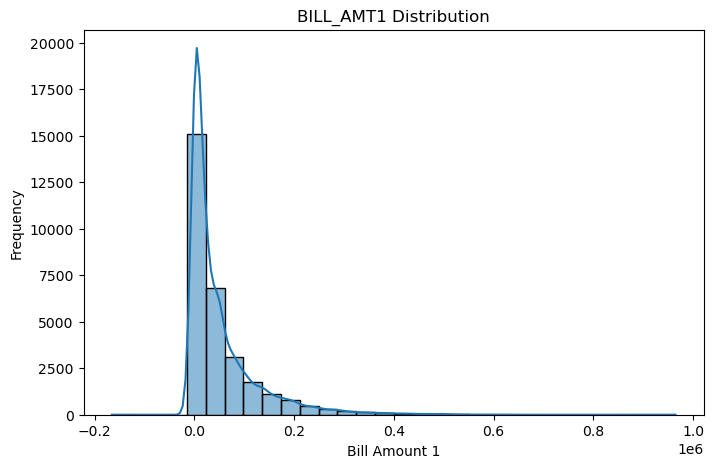

In [17]:
# Step 23: Distribution of BILL_AMT1

plt.figure(figsize=(8,5))

sns.histplot(df['BILL_AMT1'], bins=30, kde=True)

plt.title('BILL_AMT1 Distribution')
plt.xlabel('Bill Amount 1')
plt.ylabel('Frequency')

plt.show()

### Step 24: BILL_AMT1 Analysis Interpretation

- The distribution of BILL_AMT1 is highly right-skewed.
- Most customers have lower bill amounts, while a few customers have extremely high bill amounts.
- Some negative bill values are also present, which may indicate adjustments or overpayments.
- Presence of extreme values suggests possible outliers in the dataset.
- Bill amount may significantly influence customer default behavior.

### Step 25: Correlation Heatmap

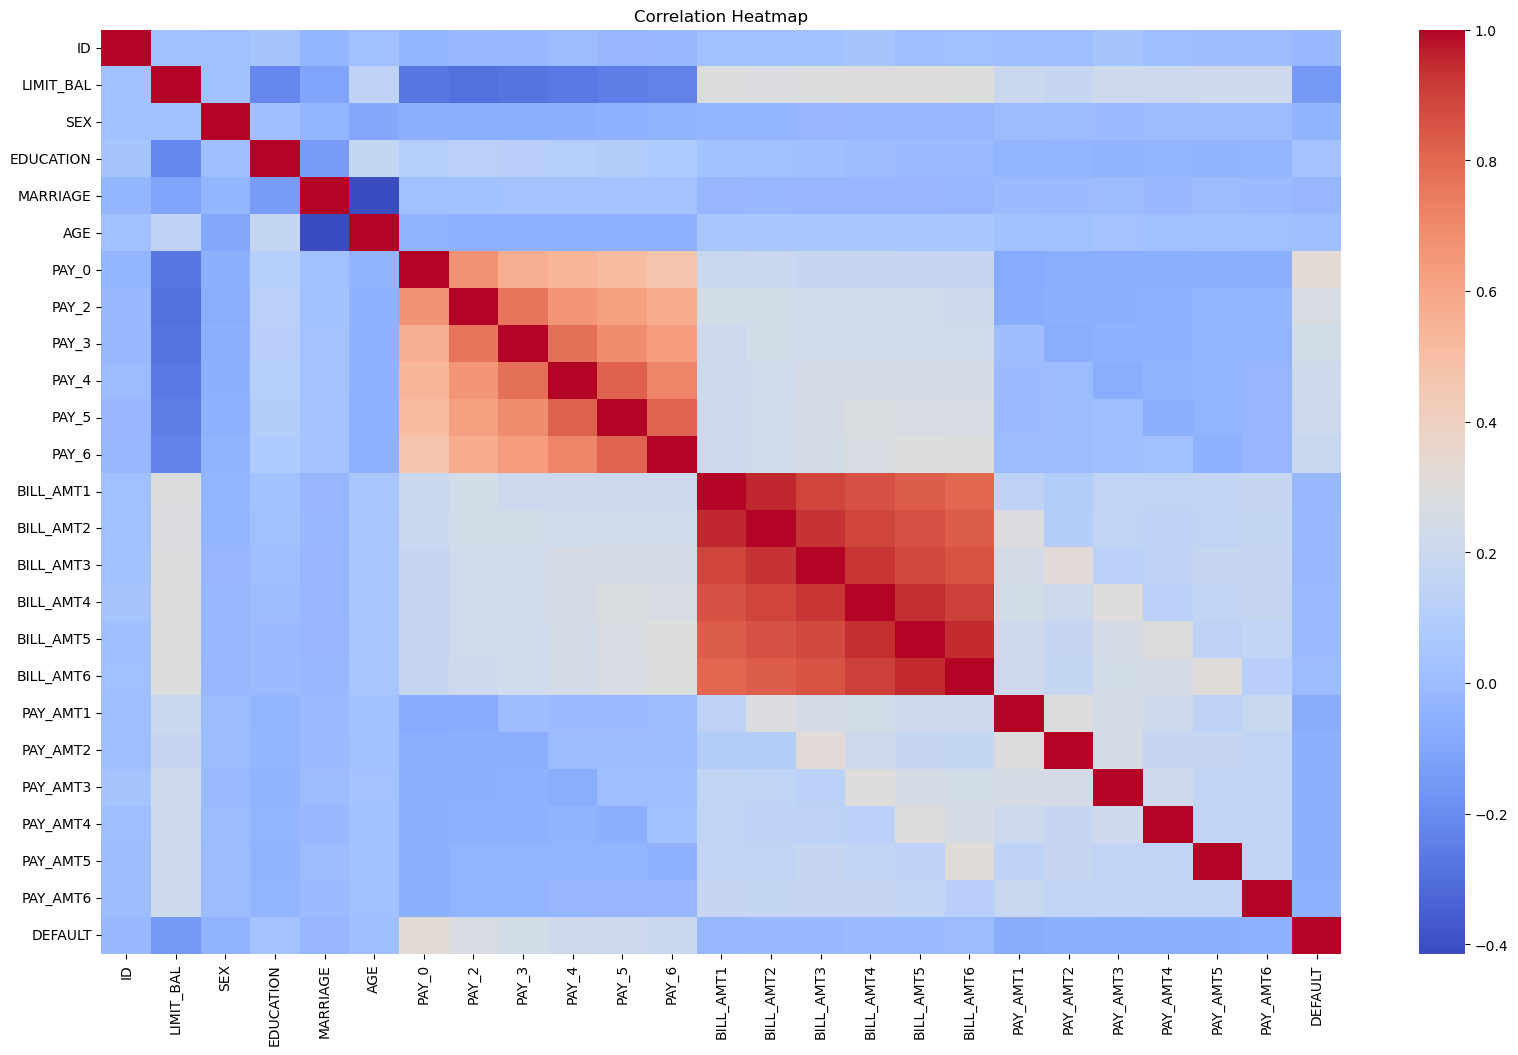

In [18]:
# Step 25: Correlation Heatmap

plt.figure(figsize=(20,12))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

### Step 26: Correlation Heatmap Interpretation

- Strong positive correlation is observed among BILL_AMT variables, indicating that customers with high bill amounts in one month tend to have high bill amounts in other months as well.
- Repayment status variables (PAY_0 to PAY_6) also show strong positive correlation with each other.
- The target variable DEFAULT shows positive correlation with repayment status variables, especially PAY_0, PAY_2, and PAY_3.
- LIMIT_BAL shows slight negative correlation with DEFAULT, suggesting that customers with higher credit limits may have lower default probability.
- Demographic variables such as SEX, EDUCATION, and MARRIAGE show relatively weak correlation with DEFAULT.

### Step 27: Boxplot for LIMIT_BAL

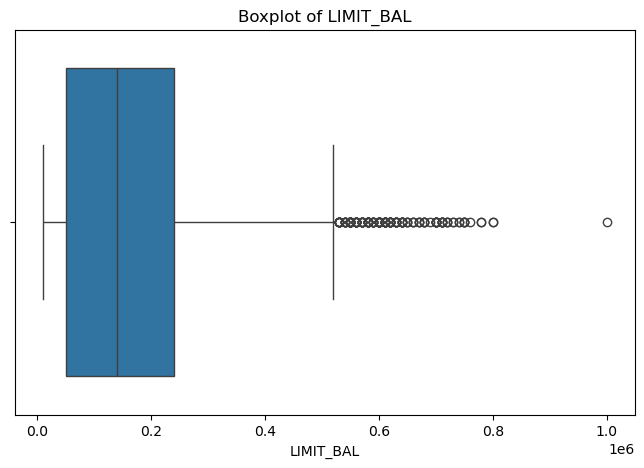

In [19]:
# Step 27: Boxplot for LIMIT_BAL

plt.figure(figsize=(8,5))

sns.boxplot(x=df['LIMIT_BAL'])

plt.title('Boxplot of LIMIT_BAL')

plt.show()

### Step 28: Boxplot for BILL_AMT1

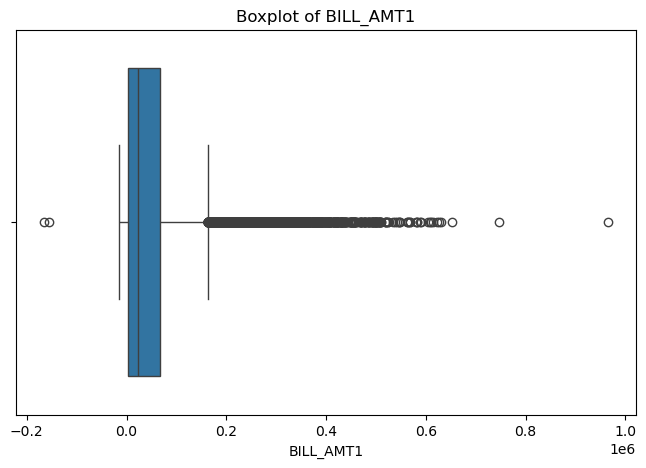

In [20]:
# Step 28: Boxplot for BILL_AMT1

plt.figure(figsize=(8,5))

sns.boxplot(x=df['BILL_AMT1'])

plt.title('Boxplot of BILL_AMT1')

plt.show()

### Step 29: Boxplot Interpretation

## Outlier Analysis using Boxplots

### LIMIT_BAL
- The boxplot of LIMIT_BAL shows the presence of several high-value outliers.
- Most customers have lower credit limits, while a few customers possess extremely high credit limits.
- The distribution is positively skewed.

### BILL_AMT1
- BILL_AMT1 also contains significant outliers on the higher side.
- A small number of customers have extremely high bill amounts compared to the majority.
- Negative bill amounts are also visible, which may represent refunds or overpayments.

### Step 30: Separate Features and Target Variable


In [21]:
# Step 30: Separate Features and Target Variable

X = df.drop('DEFAULT', axis=1)

y = df['DEFAULT']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (30000, 24)
Target Shape: (30000,)


### Step 31: Train-Test Split

In [22]:
# Step 31: Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (24000, 24)
X_test Shape: (6000, 24)
y_train Shape: (24000,)
y_test Shape: (6000,)


### Step 32: Feature Scaling

In [23]:
# Step 32: Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaled Training Data Shape:", X_train_scaled.shape)
print("Scaled Testing Data Shape:", X_test_scaled.shape)

Scaled Training Data Shape: (24000, 24)
Scaled Testing Data Shape: (6000, 24)


### Step 33: Train Logistic Regression Model


In [24]:
# Step 33: Train Logistic Regression Model

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Step 34: Predict on Test Data

In [25]:
# Step 34: Predictions using Logistic Regression

y_pred_log = log_model.predict(X_test_scaled)

### Step 35: Accuracy Score

In [26]:
# Step 35: Accuracy Score

from sklearn.metrics import accuracy_score

log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.808


### Step 36: Classification Report

In [27]:
# Step 36: Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000



### Step 37: Confusion Matrix


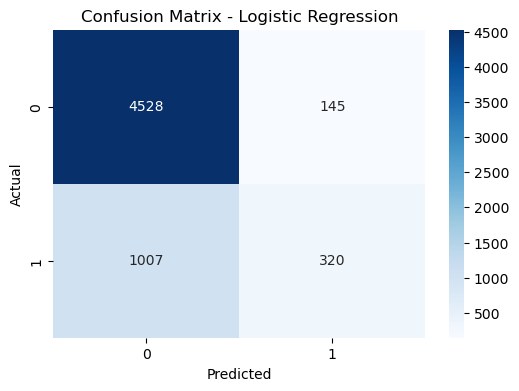

In [28]:
# Step 37: Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()


### Step 38: Logistic Regression Interpretation

- Logistic Regression achieved an accuracy of approximately 80.8%.
- The model performs very well in identifying non-default customers.
- Precision for the default class is moderate, indicating reasonable prediction quality for defaulters.
- Recall for the default class is relatively low, meaning many actual defaulters are not correctly identified.
- The confusion matrix shows that the model predicts non-default customers more accurately than default customers.
- This behavior is common in moderately imbalanced datasets.
- Logistic Regression serves as a good baseline classification model for this project.

# Decision Tree Classifier 🌳

### Step 39: Train Decision Tree Model

In [29]:
# Step 39: Train Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

### Step 40: Predictions using Decision Tree

In [30]:
# Step 40: Predictions using Decision Tree

y_pred_dt = dt_model.predict(X_test)

### Step 41: Accuracy Score

In [31]:
# Step 41: Decision Tree Accuracy

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.7233333333333334


### Step 42: Classification Report

In [32]:
# Step 42: Classification Report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.83      0.81      0.82      4673
           1       0.38      0.40      0.39      1327

    accuracy                           0.72      6000
   macro avg       0.60      0.61      0.61      6000
weighted avg       0.73      0.72      0.73      6000



### Step 43: Confusion Matrix

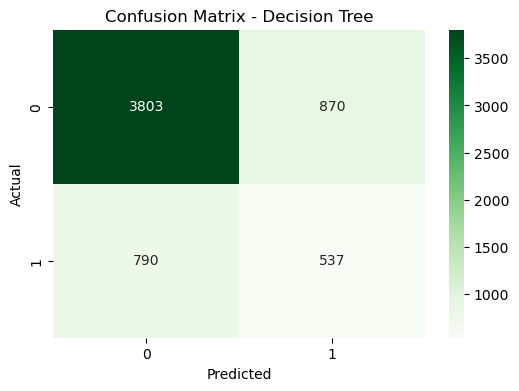

In [33]:
# Step 43: Confusion Matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))

sns.heatmap(cm_dt,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Step 44: Decision Tree Interpretation

- Decision Tree Classifier achieved an accuracy of approximately 72.3%.
- The model identifies default customers better than Logistic Regression, as indicated by higher recall for the default class.
- Recall for defaulters improved significantly compared to Logistic Regression.
- However, overall accuracy decreased due to increased false positive predictions.
- The confusion matrix shows that the model is more aggressive in predicting defaults.
- Decision Tree may capture nonlinear relationships better than Logistic Regression.
- The model is more interpretable and easier to visualize compared to complex algorithms.

# Random Forest Classifier 🌲🌲🌲

### Step 45: Train Random Forest Model

In [34]:
# Step 45: Train Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Step 46: Predictions using Random Forest

In [35]:
# Step 46: Predictions using Random Forest

y_pred_rf = rf_model.predict(X_test)


### Step 47: Accuracy Score

In [36]:
# Step 47: Random Forest Accuracy

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8136666666666666


### Step 48: Classification Report

In [37]:
# Step 48: Classification Report

print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.64      0.37      0.47      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.68      6000
weighted avg       0.79      0.81      0.79      6000



### Step 49: Confusion Matrix


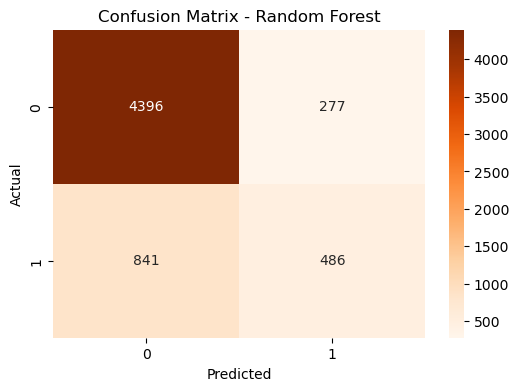

In [40]:
# Step 49: Confusion Matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Oranges')

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Step 50: Random Forest Interpretation

- Random Forest achieved the highest accuracy among the tested models, approximately 81.4%.
- The model performed well in identifying both default and non-default customers.
- Precision and F1-score for the default class improved compared to Logistic Regression and Decision Tree.
- Random Forest reduced overfitting by combining multiple decision trees.
- The confusion matrix indicates better overall classification performance.
- Random Forest appears to be the best-performing model so far for credit card default prediction.

### Step 51: Train KNN Model

In [42]:
# Step 51: Train KNN Classifier

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### Step 52: Predictions using KNN

In [43]:
# Step 52: Predictions using KNN

y_pred_knn = knn_model.predict(X_test_scaled)

### Step 53: Accuracy Score

In [45]:
# Step 53: KNN Accuracy

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.7935


### Step 54: Classification Report

In [46]:
# Step 54: Classification Report

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      4673
           1       0.55      0.35      0.43      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.63      0.65      6000
weighted avg       0.77      0.79      0.77      6000



### Step 55: Confusion Matrix

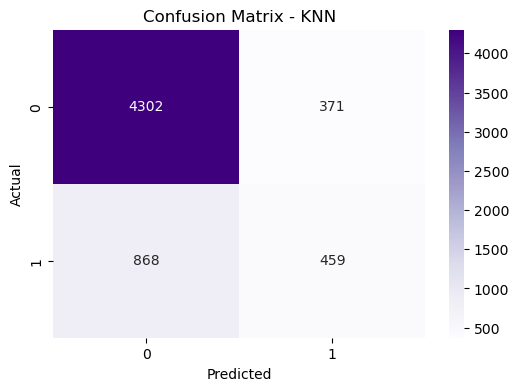

In [47]:
# Step 55: Confusion Matrix

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,4))

sns.heatmap(cm_knn,
            annot=True,
            fmt='d',
            cmap='Purples')

plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Step 56: KNN Interpretation

- KNN achieved an accuracy of approximately 79.3%.
- The model performed reasonably well for non-default customers.
- Recall for default customers improved compared to Logistic Regression.
- KNN depends heavily on feature scaling because it uses distance calculations.
- Although KNN performed better than Decision Tree in some metrics, Random Forest still achieved the best overall performance.



### Step 57: Final Model Comparison Table

In [48]:
# Step 57: Final Model Comparison

model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN'
    ],
    
    'Accuracy': [
        log_accuracy,
        dt_accuracy,
        rf_accuracy,
        knn_accuracy
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.808000
1,Decision Tree,0.723333
2,Random Forest,0.813667
3,KNN,0.793500


### Step 58: Visualize Model Accuracy

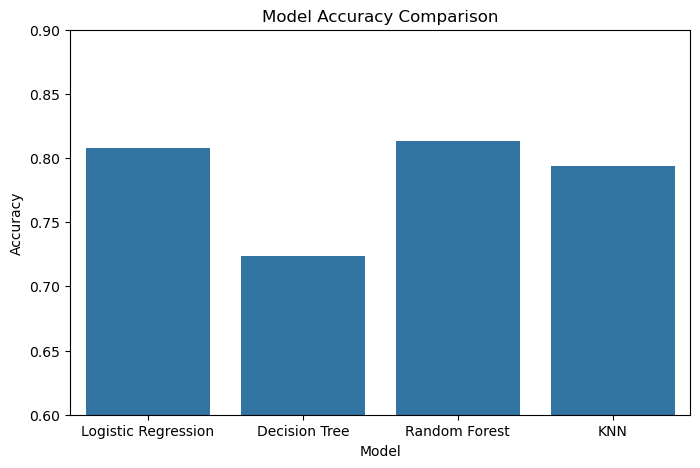

In [49]:
# Step 58: Model Accuracy Comparison

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=model_results
)

plt.title('Model Accuracy Comparison')

plt.ylim(0.6, 0.9)

plt.show()

### Step 59: Final Conclusion

- Multiple machine learning classification models were developed to predict credit card default payment behavior.
- Exploratory Data Analysis (EDA) helped identify important patterns, distributions, correlations, and outliers in the dataset.
- Data preprocessing included train-test splitting and feature scaling for distance-based models.
- Logistic Regression, Decision Tree, Random Forest, and KNN classifiers were trained and evaluated.
- Among all models, Random Forest achieved the highest accuracy of approximately 81.37% and showed the best overall performance.
- KNN and Logistic Regression also produced competitive results, while Decision Tree showed comparatively lower performance.
- The dataset was slightly imbalanced, which affected the prediction performance for default customers (Class 1).
- This project demonstrates how machine learning techniques can assist financial institutions in identifying potential credit defaulters and improving risk management strategies.

### Model Saving Code


In [51]:
# Save trained model and scaler

import pickle

with open("random_forest_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Model and scaler saved successfully.")

Model and scaler saved successfully.
